In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path



In [2]:
file_dir = Path.cwd() / './data' 
file_dir
cars_csv_path = file_dir / "car-sales-extended-missing-data.csv"
housing_csv_path = file_dir / "housing.csv"



In [3]:
df = pd.read_csv(cars_csv_path)
df.head()

,Make,Colour,Odometer (KM),Doors,Price
0,Honda,White,35431.0,4.0,15323.0
1,BMW,Blue,192714.0,5.0,19943.0
2,Honda,White,84714.0,4.0,28343.0
3,Toyota,White,154365.0,4.0,13434.0
4,Nissan,Blue,181577.0,3.0,14043.0


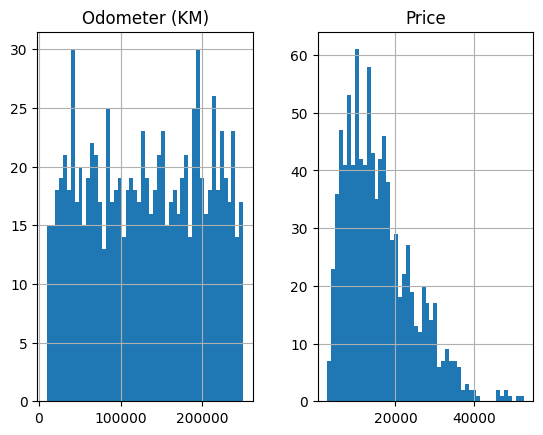

In [4]:
cols_num = ['Odometer (KM)', 'Price']
df[cols_num].hist(bins=50)
plt.show()

In [5]:
# from sklearn.ensemble import IsolationForest
# iso_f = IsolationForest(n_estimators=200,contamination=0.01)
# pred = iso_f.fit_predict(df[['Price']])
# outliers_mask = pred == -1

# plt.hist(df.loc[~outliers_mask, 'Price'], bins=50, color='b')
# plt.hist(df.loc[outliers_mask, 'Price'], bins=50, color='r')
# plt.show()



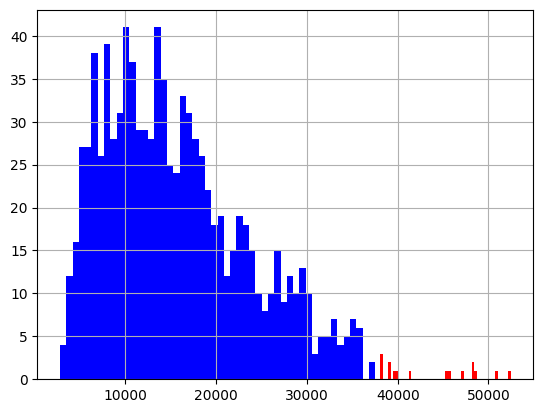

In [6]:

q1,m,q3 = df['Price'].quantile([0.25,0.5,0.75])
q1,m,q3
iqr = np.abs(q1-q3)
lower_limit = q1 - 1.5*iqr
upper_limit = q3 + 1.5*iqr

upper_outlier = df['Price'] > upper_limit
lower_limit = df['Price'] < lower_limit
outlier_mask = upper_outlier | lower_limit
df.loc[outlier_mask,'Price'].hist(bins = 50,color='red')
df.loc[~outlier_mask,'Price'].hist(bins = 50,color='blue')
plt.show()

In [7]:
df2 = df.loc[~outlier_mask]
df2

,Make,Colour,Odometer (KM),Doors,Price
0,Honda,White,35431.0,4.0,15323.0
1,BMW,Blue,192714.0,5.0,19943.0
2,Honda,White,84714.0,4.0,28343.0
3,Toyota,White,154365.0,4.0,13434.0
4,Nissan,Blue,181577.0,3.0,14043.0
...,...,...,...,...,...
995,Toyota,Black,35820.0,4.0,32042.0
996,NaN,White,155144.0,3.0,5716.0
997,Nissan,Blue,66604.0,4.0,31570.0
998,Honda,White,215883.0,4.0,4001.0


In [8]:
num_cols = ['Odometer (KM)', 'Price']
cat_cols = ['Make','Colour','Doors']

In [9]:
from sklearn.impute import SimpleImputer

ss_num = SimpleImputer(strategy='median')
output1 = ss_num.fit_transform(df2[num_cols])

ss_cat = SimpleImputer(strategy='most_frequent')
output2 = ss_cat.fit_transform(df2[cat_cols])
output2

array([['Honda', 'White', 4.0],
       ['BMW', 'Blue', 5.0],
       ['Honda', 'White', 4.0],
       ...,
       ['Nissan', 'Blue', 4.0],
       ['Honda', 'White', 4.0],
       ['Toyota', 'Blue', 4.0]], shape=(984, 3), dtype=object)

In [10]:
df2.loc[:,num_cols] = output1
df2.loc[:,cat_cols] = output2
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 984 entries, 0 to 999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Make           984 non-null    object 
 1   Colour         984 non-null    object 
 2   Odometer (KM)  984 non-null    float64
 3   Doors          984 non-null    float64
 4   Price          984 non-null    float64
dtypes: float64(3), object(2)
memory usage: 46.1+ KB


In [11]:
df2.head()

,Make,Colour,Odometer (KM),Doors,Price
0,Honda,White,35431.0,4.0,15323.0
1,BMW,Blue,192714.0,5.0,19943.0
2,Honda,White,84714.0,4.0,28343.0
3,Toyota,White,154365.0,4.0,13434.0
4,Nissan,Blue,181577.0,3.0,14043.0


In [12]:
from sklearn.preprocessing import OrdinalEncoder
# ord_enc.categories_
ord_enc = OrdinalEncoder()
output = ord_enc.fit_transform(df2[['Make']])
output

array([[1.],
       [0.],
       [1.],
       [3.],
       [2.],
       [1.],
       [3.],
       [1.],
       [3.],
       [1.],
       [2.],
       [2.],
       [2.],
       [3.],
       [1.],
       [3.],
       [3.],
       [0.],
       [2.],
       [2.],
       [3.],
       [1.],
       [3.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [3.],
       [2.],
       [3.],
       [2.],
       [2.],
       [1.],
       [1.],
       [2.],
       [2.],
       [2.],
       [3.],
       [3.],
       [3.],
       [1.],
       [3.],
       [3.],
       [2.],
       [3.],
       [3.],
       [2.],
       [3.],
       [3.],
       [1.],
       [3.],
       [3.],
       [3.],
       [1.],
       [0.],
       [3.],
       [3.],
       [0.],
       [1.],
       [1.],
       [1.],
       [3.],
       [0.],
       [3.],
       [3.],
       [3.],
       [0.],
       [2.],
       [3.],
       [1.],
       [3.],
       [3.],
       [3.],
       [3.],
       [3.],

In [13]:
from sklearn.preprocessing import OneHotEncoder
onehot_enc = OneHotEncoder(sparse_output=False)

onehot_output = onehot_enc.fit_transform(df2[['Make']]) # type: DataFrame
onehot_output

array([[0., 1., 0., 0.],
       [1., 0., 0., 0.],
       [0., 1., 0., 0.],
       ...,
       [0., 0., 1., 0.],
       [0., 1., 0., 0.],
       [0., 0., 0., 1.]], shape=(984, 4))

In [14]:
pd.DataFrame(onehot_output, columns=onehot_enc.get_feature_names_out())

,Make_BMW,Make_Honda,Make_Nissan,Make_Toyota
0,0.0,1.0,0.0,0.0
1,1.0,0.0,0.0,0.0
2,0.0,1.0,0.0,0.0
3,0.0,0.0,0.0,1.0
4,0.0,0.0,1.0,0.0
...,...,...,...,...
979,0.0,0.0,0.0,1.0
980,0.0,0.0,0.0,1.0
981,0.0,0.0,1.0,0.0
982,0.0,1.0,0.0,0.0


In [15]:
df2

,Make,Colour,Odometer (KM),Doors,Price
0,Honda,White,35431.0,4.0,15323.0
1,BMW,Blue,192714.0,5.0,19943.0
2,Honda,White,84714.0,4.0,28343.0
3,Toyota,White,154365.0,4.0,13434.0
4,Nissan,Blue,181577.0,3.0,14043.0
...,...,...,...,...,...
995,Toyota,Black,35820.0,4.0,32042.0
996,Toyota,White,155144.0,3.0,5716.0
997,Nissan,Blue,66604.0,4.0,31570.0
998,Honda,White,215883.0,4.0,4001.0


In [16]:
cat_cols = ['Make',	'Colour','Doors']
df2.loc[:,cat_cols]


,Make,Colour,Doors
0,Honda,White,4.0
1,BMW,Blue,5.0
2,Honda,White,4.0
3,Toyota,White,4.0
4,Nissan,Blue,3.0
...,...,...,...
995,Toyota,Black,4.0
996,Toyota,White,3.0
997,Nissan,Blue,4.0
998,Honda,White,4.0


In [17]:
outp = onehot_enc.fit_transform(df2.loc[:,cat_cols])
pd.DataFrame(outp,columns=onehot_enc.get_feature_names_out())

,Make_BMW,Make_Honda,Make_Nissan,Make_Toyota,Colour_Black,Colour_Blue,Colour_Green,Colour_Red,Colour_White,Doors_3.0,Doors_4.0,Doors_5.0
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
979,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
980,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
981,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
982,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [18]:
from sklearn.preprocessing import TargetEncoder
t_enc = TargetEncoder()
t_enc.fit_transform(df2[['Make']],df2['Price'])

array([[14659.31275274],
       [22920.42981057],
       [14372.64162426],
       [15318.45241097],
       [13812.81560896],
       [14620.48813121],
       [15636.60591003],
       [14733.73252397],
       [15562.56501245],
       [14628.46253761],
       [13785.51888005],
       [13785.51888005],
       [13812.81560896],
       [15241.51470413],
       [14628.46253761],
       [15562.56501245],
       [15318.45241097],
       [22920.42981057],
       [13684.03579627],
       [13365.15427875],
       [15636.60591003],
       [14733.73252397],
       [15334.84589357],
       [14733.73252397],
       [14733.73252397],
       [14372.64162426],
       [14628.46253761],
       [14628.46253761],
       [14628.46253761],
       [15636.60591003],
       [13365.15427875],
       [15562.56501245],
       [13811.62869134],
       [13785.51888005],
       [14733.73252397],
       [14620.48813121],
       [13785.51888005],
       [13812.81560896],
       [13365.15427875],
       [15562.56501245],


In [19]:
df3 = pd.read_csv(housing_csv_path)
df3.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


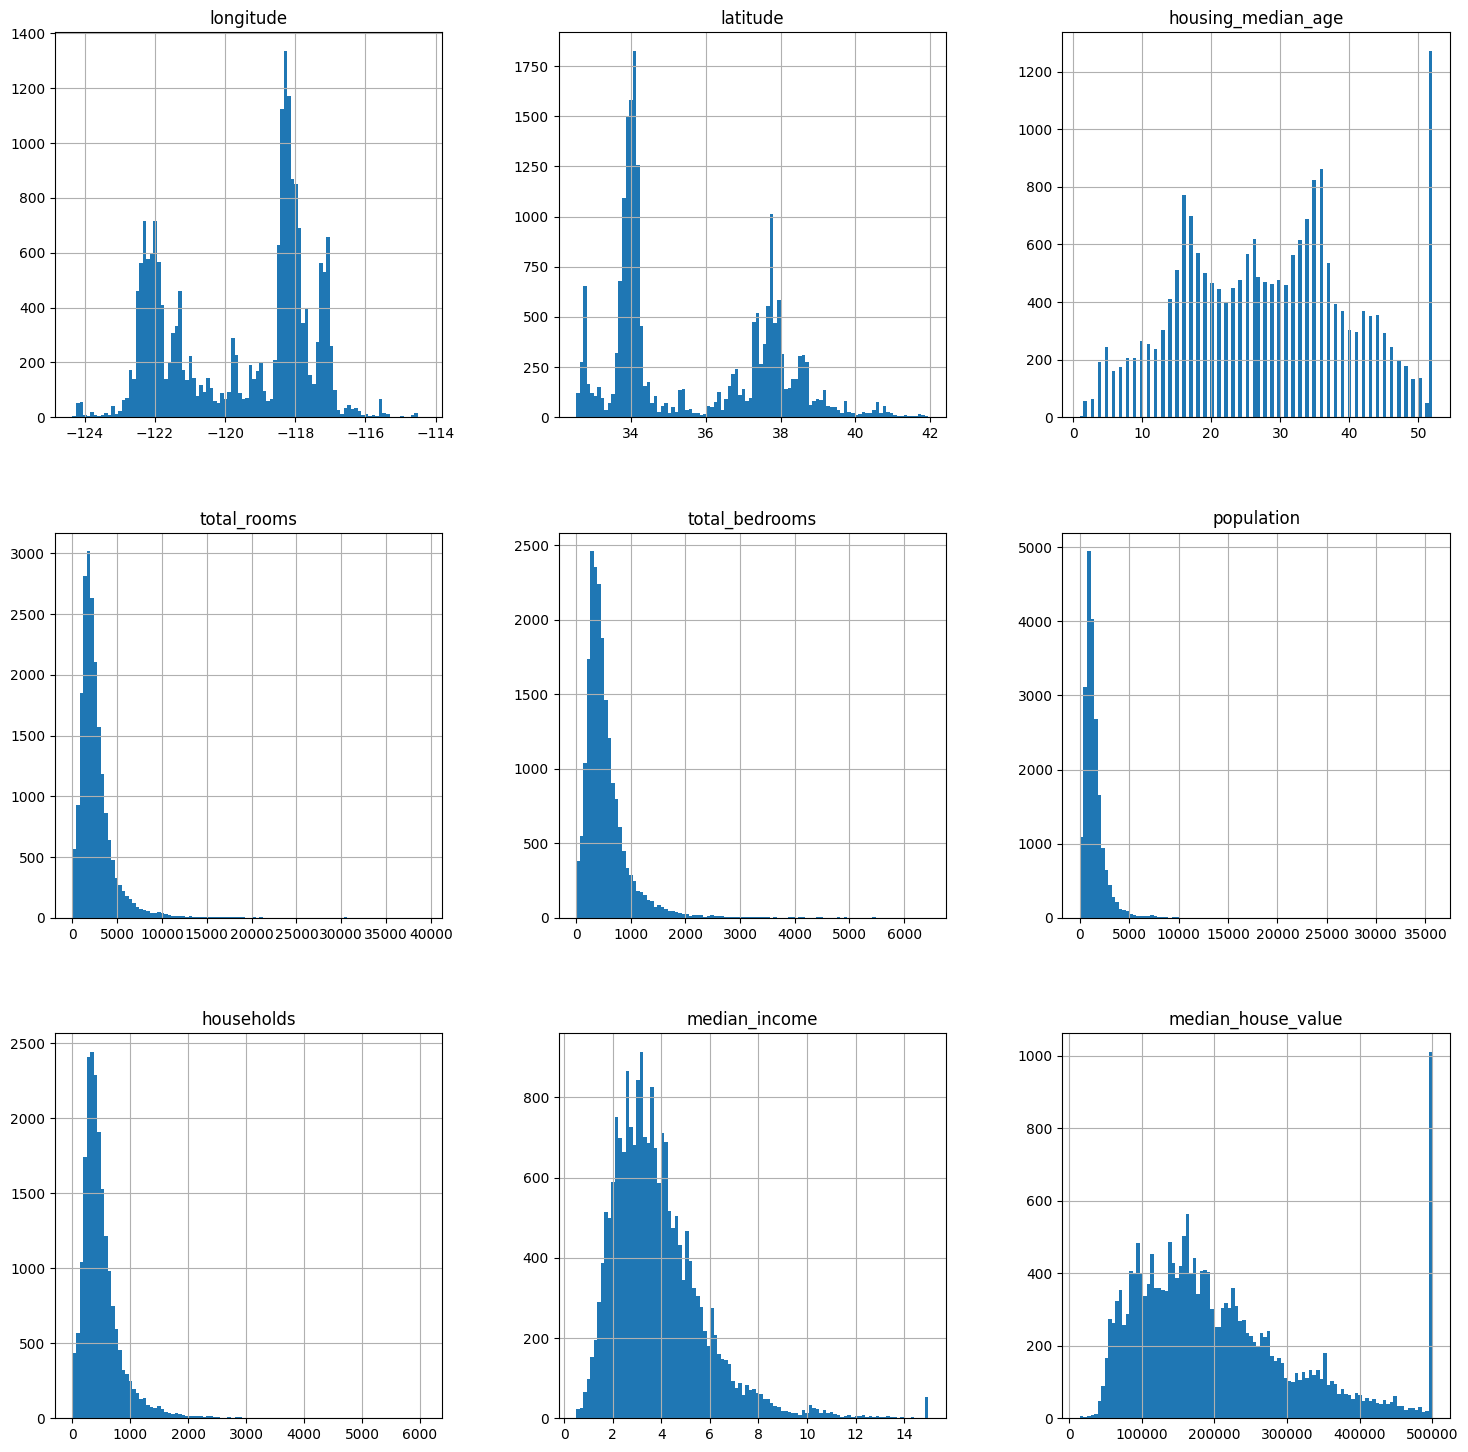

In [20]:
import matplotlib.pyplot as plt
df3_num = df3.select_dtypes('number')
df3_num.hist(figsize=(18,18),bins=100)
plt.show()

In [21]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
output_ss = ss.fit_transform(df3[['medin_income']]) # sixisdirilir ve shift edir

fig, axs = plt.subplots(nrows=2,ncols=2)
axs[0,0].hist(df3['median_income'],bins=50,color='b')
axs[0,1].hist(output_ss,bins=50,color='r')
fig.show()

KeyError: "None of [Index(['medin_income'], dtype='object')] are in the [columns]"